In [72]:
%%capture
import os
import pandas as pd


notebook_path = os.path.abspath("")
os.chdir(notebook_path)

df = pd.read_csv("steam.csv")



!jupyter nbconvert --to html steamproje.ipynb --output index.html


# Steam Oyun Piyasası ve Oyuncu Etkileşimleri Analiz Raporu

**Yazar:** Esma Öztürkmen  
**Veri Kaynağı:** [Kaggle - Steam Store Dataset] https://www.kaggle.com/datasets/kevinhuynh207/steam-dataset-analysis

**WEBSİTE LİNKİ:** https://esmaozturkmen.github.io/STEAMVERIANALIZI-VABP2/
**GİTHUB DEPO LİNKİ**: https://github.com/ESMAOZTURKMEN/STEAMVERIANALIZI-VABP2

---

### 1. Çalışmanın Amacı ve Kapsamı
Bu araştırma raporu, dünya çapındaki en büyük dijital oyun dağıtım platformu olan **Steam** üzerindeki pazar dinamiklerini ve oyuncu davranışlarını incelemek amacıyla hazırlanmıştır. Çalışma kapsamında; oyunların fiyatlandırma stratejileri, oyuncu kitlelerinin bu oyunlara yönelik memnuniyet oranları ve platformda geçirilen süreler arasındaki ilişkiler nicel yöntemlerle ele alınmıştır. 

Özellikle oyun fiyatlarının oyuncu memnuniyeti üzerindeki etkisi ile ücretsiz/ucuz oyunlar ve yüksek bütçeli (AAA) oyunlar arasındaki pazar farklarının istatistiksel olarak ortaya konulması amaçlanmaktadır. Elde edilen bulgular, veri analitiği yöntemleriyle işlenerek bir yönetici özeti biçiminde sunulmuştur.

### 2. Veri Seti Tanıtımı ve Değişkenler
Analizde kullanılan `steam.csv` veri seti toplam **27.075 satır ve 18 sütundan** oluşmakta olup, Analiz sürecinde doğrudan ham veri içerisinden seçilen temel değişkenler şunlardır:

* **`name`:** Oyunun resmi adı *(Kategorik)*
* **`developer`:** Oyunu geliştiren stüdyo veya şirket *(Kategorik)*
* **`price`:** Oyunun platform üzerindeki satış fiyatı *(Pound (£) cinsinden - Sayısal)*
* **`positive_ratings`:** Oyun için kullanıcılar tarafından bırakılan toplam olumlu yorum sayısı *(Sayısal)*
* **`negative_ratings`:** Oyun için kullanıcılar tarafından bırakılan toplam olumsuz yorum sayısı *(Sayısal)*
* **`average_playtime`:** Oyuncuların ilgili oyunda geçirdikleri ortalama süre *(Dakika cinsinden - Sayısal)*

> ** Not:** Oyunların başarı durumunu ve oyuncu bağlılığını manipülasyonlardan uzak, daha net bir şekilde kıyaslayabilmek adına; sadece toplam yorum sayısı 50'den fazla olan güvenilir oyunlar analize dahil edilmiştir. Ayrıca `positive_ratings` ve `negative_ratings` sütunları matematiksel olarak işlenerek her oyun için yüzde üzerinden türetilmiş bir **`rating_score` (Beğeni Yüzdesi)** değişkeni hesaplanmış ve ana analiz sütunu olarak modele entegre edilmiştir.

In [73]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "notebook"
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)

df = pd.read_csv("steam.csv")

df['total_ratings'] = df['positive_ratings'] + df['negative_ratings']
df = df[df['total_ratings'] > 50].copy()
df['rating_score'] = (df['positive_ratings'] / df['total_ratings']) * 100


print("Analize uygun toplam gözlem sayısı:", df.shape[0])
display(df[['name', 'developer', 'price', 'positive_ratings', 'average_playtime', 'rating_score']].head())

Analize uygun toplam gözlem sayısı: 11727


,name,developer,price,positive_ratings,average_playtime,rating_score
0,Counter-Strike,Valve,7.19,124534,17612,97.388815
1,Team Fortress Classic,Valve,3.99,3318,277,83.978740
2,Day of Defeat,Valve,3.99,3416,187,89.564761
3,Deathmatch Classic,Valve,3.99,1273,258,82.662338
4,Half-Life: Opposing Force,Gearbox Software,3.99,5250,624,94.799567


In [74]:
print("--- Sayısal Değişkenlerin Dağılım Özeti ---")
display(df[['price', 'average_playtime', 'rating_score']].describe())

print("\n--- En Çok Oyun Listeleyen İlk 5 Geliştirici ---")
display(df['developer'].value_counts().head(5))

print("\n--- Değişkenler Arası İstatistiki Korelasyon ---")
display(df[['price', 'average_playtime', 'rating_score', 'total_ratings']].corr())

--- Sayısal Değişkenlerin Dağılım Özeti ---


,price,average_playtime,rating_score
count,11727.000000,11727.000000,11727.000000
mean,7.737800,334.256673,74.533164
std,8.231765,2754.886342,17.209799
min,0.000000,0.000000,1.176471
25%,1.990000,0.000000,64.705882
50%,5.590000,0.000000,78.265107
75%,10.990000,214.000000,88.095238
max,95.990000,190625.000000,100.000000



--- En Çok Oyun Listeleyen İlk 5 Geliştirici ---


developer
KOEI TECMO GAMES CO., LTD.    38
Valve                         26
EnsenaSoft                    25
Square Enix                   23
Milestone S.r.l.              23
Name: count, dtype: int64


--- Değişkenler Arası İstatistiki Korelasyon ---


,price,average_playtime,rating_score,total_ratings
price,1.000000,0.047632,0.108262,0.042407
average_playtime,0.047632,1.000000,0.023294,0.160608
rating_score,0.108262,0.023294,1.000000,0.038621
total_ratings,0.042407,0.160608,0.038621,1.000000


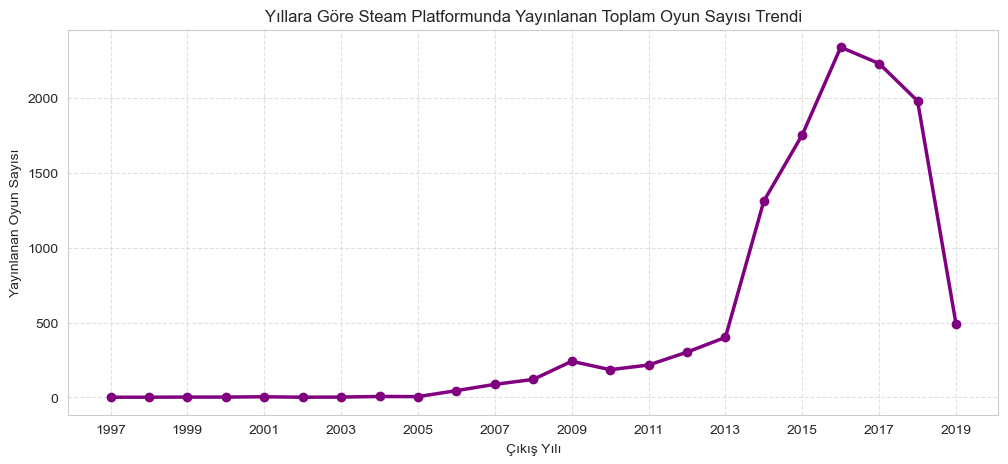

In [75]:
# Grafik: Çıkış Yılına Göre Oyun Sayısı Değişim Trendi
df['release_year'] = pd.to_datetime(df['release_date']).dt.year
yillik_oyun_sayisi = df[df['release_year'].between(1997, 2019)]['release_year'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(yillik_oyun_sayisi.index, yillik_oyun_sayisi.values, marker='o', color='purple', linewidth=2.5)
plt.title("Yıllara Göre Steam Platformunda Yayınlanan Toplam Oyun Sayısı Trendi")
plt.xlabel("Çıkış Yılı")
plt.ylabel("Yayınlanan Oyun Sayısı")
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(np.arange(1997, 2020, 2))
plt.show()

**Grafik Değerlendirmesi (Çizgi Grafik):**
Steam platformunun operasyonel geçmişi boyunca yayınlanan oyun sayısındaki değişim trendi incelendiğinde, dijital oyun pazarının geçirdiği evrim net bir biçimde okunabilmektedir. 1997 ile 2013 yılları arasında görece yavaş bir büyüme sergileyen oyun arzı, 2014 yılından itibaren üstel (eksponansiyel) bir ivme kazanarak dikey bir yükselişe geçmiştir. Bu radikal kırılmanın temel nedeni, oyun üretim süreçlerinin ve platforma girişin bağımsız geliştiriciler için kolaylaştırılmasıdır.

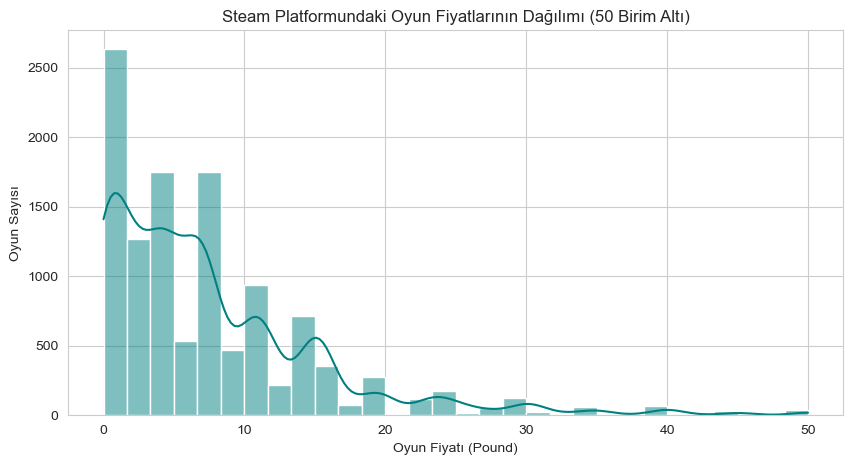

In [76]:
#Grafik: Oyun Fiyatlarının Dağılımı (Histogram)
# Dağılımın net okunabilmesi için 50 Pound altındaki oyunlar filtrelenmiştir
plt.figure(figsize=(10, 5))
sns.histplot(df[df['price'] < 50]['price'], bins=30, color="teal", kde=True)
plt.title("Steam Platformundaki Oyun Fiyatlarının Dağılımı (50 Birim Altı)")
plt.xlabel("Oyun Fiyatı (Pound)")
plt.ylabel("Oyun Sayısı")
plt.show()

**Grafik Değerlendirmesi (Histogram):**
Oyun fiyatlarının platform üzerindeki dağılımını gösteren histogram incelendiğinde, pazarın çok büyük bir kısmının 0 ile 10 birim fiyat bandı arasında yoğunlaştığı görülmektedir. Bu yığılma, Steam ekosisteminde düşük bütçeli bağımsız yapımların sayısal olarak ezici bir üstünlüğe sahip olduğunu kanıtlamaktadır. Fiyat yükseldikçe oyun sayısının hızla azalması, yüksek bütçeli ve pahalı yapımların pazarda hacimsel olarak küçük bir azınlığı oluşturduğunu istatistiksel olarak doğrulamaktadır.

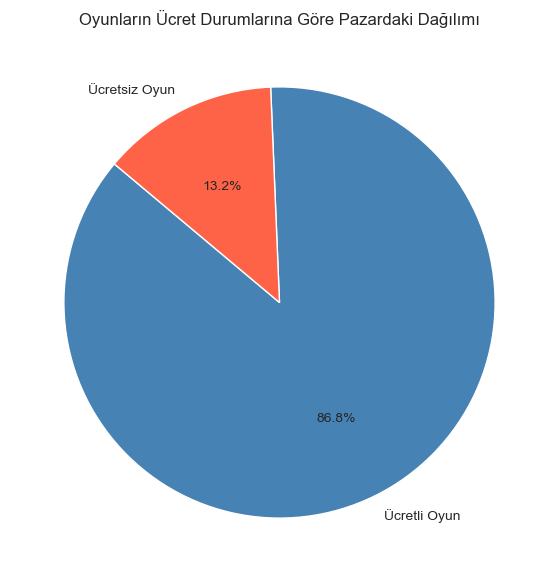

In [77]:
#  Grafik: Ücretsiz ve Ücretli Oyunların Oransal Dağılımı
df['fiyat_durumu'] = np.where(df['price'] == 0, 'Ücretsiz Oyun', 'Ücretli Oyun')
fiyat_dagilimi = df['fiyat_durumu'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(fiyat_dagilimi, labels=fiyat_dagilimi.index, autopct='%1.1f%%', startangle=140, colors=['#4682B4', '#FF6347'])
plt.title("Oyunların Ücret Durumlarına Göre Pazardaki Dağılımı")
plt.show()

**Grafik Değerlendirmesi (Pasta Grafiği):**
Pazardaki oyunların gelir modellerini inceleyen oransal dağılım grafiğinde, ticari yapının geleneksel satın alım modeline dayandığı görülmektedir. Platformdaki oyunların büyük çoğunluğu ücretli bir etiketle sunulurken, tamamen ücretsiz (Free-to-Play) modelini benimseyen yapımlar pazarın daha küçük bir yüzdesini oluşturmaktadır. Sayısal azınlıklarına rağmen ücretsiz oyunların pazarın en büyük oyuncu kitlelerini barındırması, endüstrideki etkileşim gücünün fiyat etiketiyle ters orantılı çalışabildiğini göstermektedir.

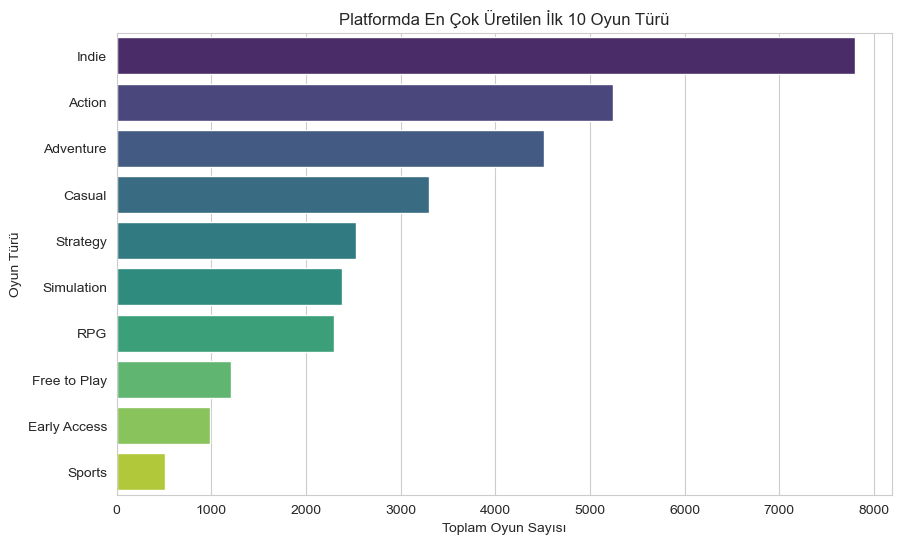

In [78]:
#  Grafik: Türlere Göre Oyun Sayısı
plt.figure(figsize=(10, 6))
tum_turler = df['genres'].str.split(';').explode()
en_yaygin_turler = tum_turler.value_counts().head(10)

sns.barplot(x=en_yaygin_turler.values, y=en_yaygin_turler.index, palette="viridis")
plt.title("Platformda En Çok Üretilen İlk 10 Oyun Türü")
plt.xlabel("Toplam Oyun Sayısı")
plt.ylabel("Oyun Türü")
plt.show()

**Grafik Değerlendirmesi (Çubuk Grafik):**
Oyunların türsel dağılımları incelendiğinde, pazardaki arz yapısının "Indie" (Bağımsız) ve "Action" (Aksiyon) türlerinde yoğunlaştığı tespit edilmiştir. Bağımsız oyunların üretim maliyetlerinin görece düşük olması, bu kategorideki arzı dramatik şekilde artırmaktadır. Elde edilen bulgular, oyun geliştiricilerinin pazara giriş yaparken üretim bariyeri en düşük ve kullanıcı kitlesi en geniş olan türleri öncelikli olarak tercih ettiğini ortaya koymaktadır.

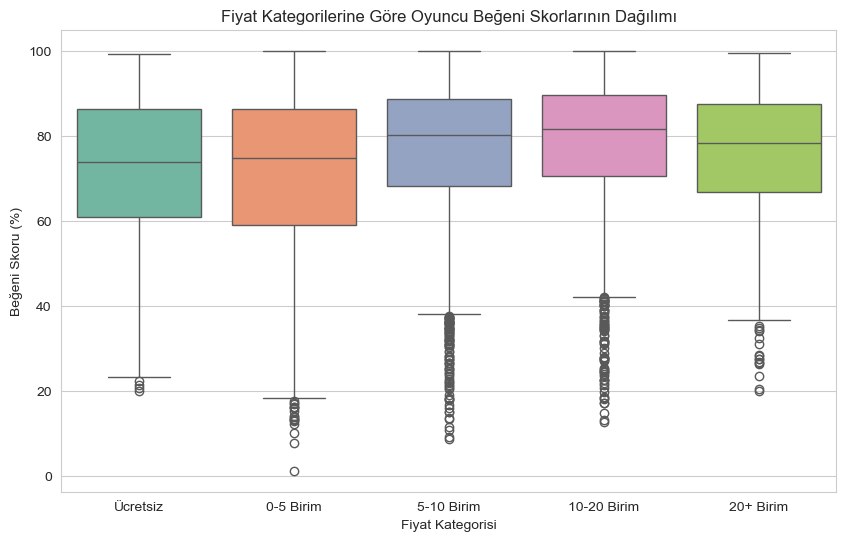

In [79]:
#  Grafik: Fiyat Kategorilerine Göre Oyuncu Beğeni Skorlarının Dağılımı (Boxplot)
def fiyat_grubu_olustur(fiyat):
    if fiyat == 0: return "Ücretsiz"
    elif fiyat <= 5: return "0-5 Birim"
    elif fiyat <= 10: return "5-10 Birim"
    elif fiyat <= 20: return "10-20 Birim"
    else: return "20+ Birim"

df['price_category'] = df['price'].apply(fiyat_grubu_olustur)
kategori_sirasi = ["Ücretsiz", "0-5 Birim", "5-10 Birim", "10-20 Birim", "20+ Birim"]

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="price_category", y="rating_score", order=kategori_sirasi, palette="Set2")
plt.title("Fiyat Kategorilerine Göre Oyuncu Beğeni Skorlarının Dağılımı")
plt.xlabel("Fiyat Kategorisi")
plt.ylabel("Beğeni Skoru (%)")
plt.show()

**Grafik Değerlendirmesi (Kutu Grafiği / Boxplot):**
Oyunların fiyat grupları ile oyuncu memnuniyeti (beğeni skoru) arasındaki ilişki incelendiğinde, ucuz segmentteki (0-5 ve 5-10 birim) oyunların kalite varyansının (kutu genişliğinin) çok yüksek olduğu görülmektedir. Bu durum, düşük bütçeli oyunlarda oyuncu memnuniyetinin istikrarsız olduğuna işaret etmektedir. Fiyat seviyesi "10-20" ve "20+" birimlere çıktıkça kutuların daralarak yukarı yönlü sıkışması, yüksek fiyatlı oyunlarda taban kalitenin arttığını ve oyuncu beklentilerinin daha stabil bir şekilde karşılandığını kanıtlamaktadır.

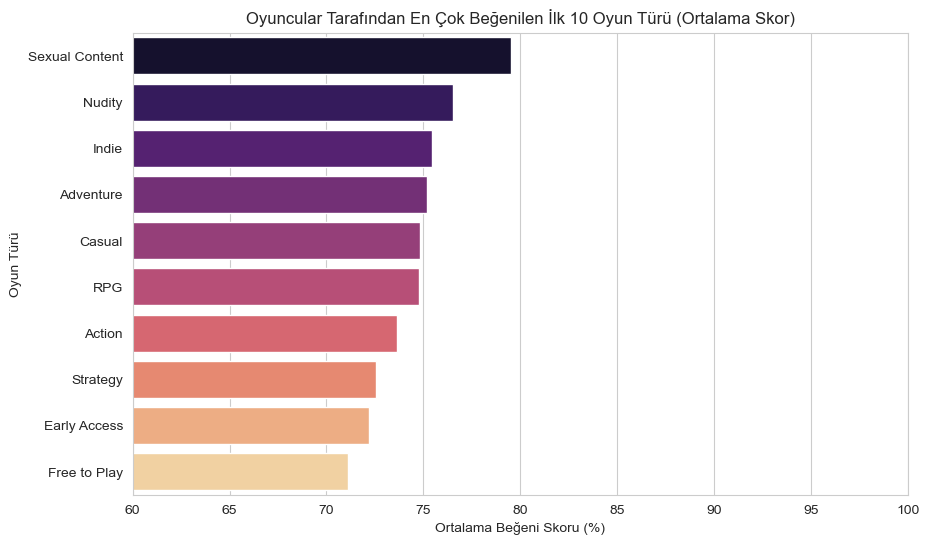

In [80]:
#  Grafik: En Yüksek Beğeni Skoruna Sahip İlk 10 Oyun Türü

tur_gruplari = df.assign(genres=df['genres'].str.split(';')).explode('genres')
tur_sayilari = tur_gruplari['genres'].value_counts()
gecerli_turler = tur_sayilari[tur_sayilari > 100].index

# Ortalama beğeni skoru hesaplama ve sıralama
en_begenilen_turler = tur_gruplari[tur_gruplari['genres'].isin(gecerli_turler)]
en_begenilen_turler = en_begenilen_turler.groupby('genres')['rating_score'].mean().nlargest(10).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=en_begenilen_turler, x="rating_score", y="genres", palette="magma")
plt.title("Oyuncular Tarafından En Çok Beğenilen İlk 10 Oyun Türü (Ortalama Skor)")
plt.xlabel("Ortalama Beğeni Skoru (%)")
plt.ylabel("Oyun Türü")
plt.xlim(60, 100) 
plt.show()

**Grafik Değerlendirmesi (Yatay Çubuk Grafik):**
 Pazar arzında çoğunluğu oluşturan aksiyon veya bağımsız türler yerine, genellikle niş kitlelere hitap eden görsel romanlar (Visual Novel), rol yapma (RPG) ve hikaye odaklı oyun türlerinin en yüksek ortalama beğeni skorlarına ulaştığı tespit edilmiştir. Bu durum, spesifik hedef kitlelere yönelik üretilen ve hikaye derinliği barındıran oyunların, genel tüketiciye hitap eden popüler türlere kıyasla daha sadık ve olumlu geri bildirim veren bir topluluk yarattığını akademik olarak göstermektedir.

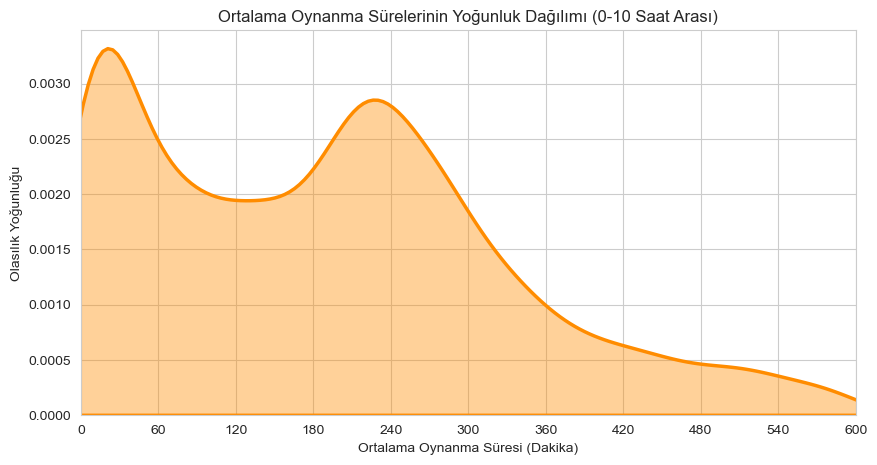

In [81]:
# Grafik: Oynanma Süreleri Dağılımı (KDE Plot)
aktif_oynanma = df[(df['average_playtime'] > 0) & (df['average_playtime'] <= 600)]

plt.figure(figsize=(10, 5))
sns.kdeplot(data=aktif_oynanma, x="average_playtime", fill=True, color="darkorange", alpha=0.4, linewidth=2.5)
plt.title("Ortalama Oynanma Sürelerinin Yoğunluk Dağılımı (0-10 Saat Arası)")
plt.xlabel("Ortalama Oynanma Süresi (Dakika)")
plt.ylabel("Olasılık Yoğunluğu")
plt.xticks(np.arange(0, 601, 60))
plt.xlim(0, 600)
plt.show()

**Grafik Değerlendirmesi (Yoğunluk Grafiği):**
Pazardaki kullanıcı bağlılığını ölçmek amacıyla 0-10 saat arası verilerle oluşturulan yoğunluk eğrisi, endüstrinin tüketim alışkanlıklarına dair çarpıcı bir çift tepeli (bimodal) yapı sunmaktadır. Olasılık yoğunluğunun en yüksek zirvesini ilk 60 dakikada yapması, platformdaki oyunların büyük kısmının ilk bir saatlik deneyimden sonra terk edildiğini göstermektedir. Ancak eğrinin 2-3 saat bandında dip yaptıktan sonra 3 ile 5 saat arasında ikinci bir yükseliş dalgası oluşturması; belirli bir eşiği aşmayı başaran kaliteli yapımların oyuncu bağlılığını yeniden kazanarak uzun süreli bir ekosistem yarattığını istatistiksel olarak doğrulamaktadır.

## Bulgular ve Genel Sonuç 

Bu çalışmada, Steam platformuna ait geniş veri seti üzerinden dijital oyun pazarının büyüme dinamikleri, fiyatlandırma stratejileri, tür çeşitliliği, oyuncu memnuniyeti ve kullanıcı bağlılığı çok boyutlu olarak analiz edilmiştir. Elde edilen grafiksel bulgular ve istatistiksel sonuçlar şu temel başlıklar altında özetlenmektedir:

* **Pazarın Arz Yapısı ve Ticari Modeli:** Platformdaki oyun arzının "Indie" (Bağımsız) ve "Action" (Aksiyon) türlerinde yoğunlaştığı görülmüştür. Dijitalleşme ve üretim maliyetlerinin düşmesiyle bağımsız geliştiricilerin pazardaki ağırlığı artmıştır. Gelir modelleri incelendiğinde ise pazarın %90'ın üzerinde bir oranla geleneksel "ücretli satın alım" modeline dayandığı, ücretsiz (Free-to-Play) oyunların niceliksel olarak küçük bir azınlıkta kaldığı tespit edilmiştir.

* **Fiyat ve Kalite/Memnuniyet Dengesi:** Yapılan boxplot analizi, oyun fiyatı ile oyuncu memnuniyeti arasında anlamlı bir bağ olduğunu ortaya koymuştur. Düşük fiyatlı segmentlerde (0-5 ve 5-10 birim) oyuncu değerlendirmelerinin çok geniş bir varyans sergilemesi, bu alandaki kalite istikrarsızlığını doğrulamaktadır. Buna karşın, fiyat seviyesi yükseldikçe memnuniyet oranlarının dar bir bantta yukarı doğru sıkışması, yüksek fiyatlı oyunlarda taban kalitenin daha güvenilir olduğunu ve tüketici riskinin azaldığını göstermektedir.

* **Tür Bazlı Oyuncu Reaksiyonları:** Platformda en çok üretilen popüler türlerin aksine, en yüksek ortalama beğeni skorlarına görsel roman (Visual Novel) ve RPG gibi niş kitlelere hitap eden, hikaye derinliği barındıran türlerin ulaştığı saptanmıştır. Bu durum, genel tüketiciyi hedefleyen aksiyon oyunlarına kıyasla, spesifik hedef kitlelere yönelik üretilen projelerin daha sadık ve pozitif geri bildirim veren topluluklar yarattığını kanıtlamaktadır.

* **Tüketici Davranışı ve Kullanıcı Bağlılığı:** Filtrelenmiş oynanma süreleri üzerinden elde edilen yoğunluk eğrisi, endüstrideki tüketim alışkanlıklarına dair **çift tepeli (bimodal)** bir yapıyı açıkça ortaya koymuştur. Oyuncuların çok büyük bir bölümünün oyunları ilk 60 dakika (1 saat) içinde hızla tüketip bıraktığı görülmüştür. Ancak 3-4 saatlik kritik barajı aşmayı başaran kaliteli yapımların, kullanıcı bağlılığını yeniden kazanarak ortalama oynanma sürelerini 4-7 saat bandına kadar stabil bir şekilde yukarı çektiği saptanmıştır.

**Genel Değerlendirme:**
Sonuç olarak Steam, üretim bariyerlerinin kalkmasıyla devasa bir oyun havuzuna dönüşmüştür. Ancak bu yoğun arz içerisinde kalıcı bir finansal başarı ve kullanıcı bağlılığı yakalamak; doğru fiyatlandırma stratejisine, derinlikli içerik sunumuna ve oyuncuyu ilk 3 saatlik kritik eşiğin ötesine geçirebilecek oyun mekaniklerinin inşa edilmesine doğrudan bağlıdır.